# Test simulator cases

Oreonspy foresees four cases based on the cavity round-trip time, required sampling frequency and chosen simulator accuracy for decaing electric field. For most of the required sampling frequency it is required an approximation to the closest computable frequency.

```real_f_calc()``` implements the algorithm used in oreonspy to choose between cases. In the second part of the notebook we attempt to test the approximation of the sampling frequency produced by the algorithm.

The most important variable in the algorithm is the number of roundtrips a photon will make inside the cavity in the timelap between two consecutive simulator samples ```N```.  The sampling frequency appoximation arises from the fact that ```N``` must be integer.

If ```N``` is smaller than one, the simulation is not possible using the difference equation. In this case, the simulator creates several simulators shifted in phase in order to satisfy the required sampling frequency.

The algorithm contains one constant (```N_epsilon```) which must be optimized for the best frequency approximation.\
Goal: Optimize ```N_epsilon```.

In [1]:
import numpy as np

def number_of_2T_chains(N_pre):
    return int(np.ceil(1.0 / N_pre))


def real_f_calc(N_pre, N_epsilon, _2T, N_eff=1000):
    """
    Simulator case algorithm from cavity.simulation() in oreonspy 3.2.3.
    """
    _N_eff_factor = 2

    case = 0
    
    if N_pre < 1.0 - N_epsilon:
        case = 0

        #logger.info("2T x times bigger then Theta. (x is integer)")
        number_of_2T_chains = int(np.ceil(1.0 / N_pre))  # Original oreons function
        number_of_2T_chains = int(np.round(1.0 / N_pre))  # Proposed alternative

        f_calc = number_of_2T_chains / _2T
        Theta = 1.0 / f_calc
        #logger.warning("Warning: approximated f_calc to: {0:.2f}".format(f_calc))
        #logger.warning("Number of chains: {0}".format(number_of_2T_chains))

    elif N_pre < 1.0 + N_epsilon:
        case = 1

        #logger.info("2T comparable with Theta so N becomes 1")
        f_calc = 1.0 / _2T
        Theta = _2T
        #logger.warning("Warning: approximated f_calc to: {0:.2f}".format(f_calc))

    else:
        N_max = _N_eff_factor * N_eff
        #logger.debug("N_max: {0}".format(N_max))
        if N_pre > N_max:
            case = 2

            #logger.info("N times Cavity decay time shorter than the sampling period")
            N = N_max
            f_calc = f_calc
            Theta = 1.0 / f_calc

            partial_Theta = True
        else:
            case = 3

            #logger.info("N times Cavity decay time longer than the sampling period")
            N = int(np.round(N_pre+0.12))  # Original oreons function
            #N = int(np.ceil(N_pre))  # Proposed alternative
            Theta = _2T * N
            f_calc = 1.0 / Theta

    return f_calc, Theta, case

# Analyse the choice of the simulator case and the sampling frequency approximation

For an arbitrarily chosen cavity, plot the number of simulators involved (```number_of_2T_chains```).

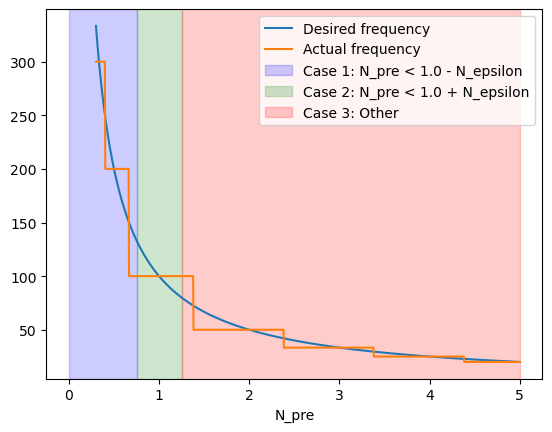

In [2]:
import matplotlib.pyplot as plt

# Define N_epsilon
N_epsilon = 0.25
_2T = 0.01

# Generate N_pre values
N_pre_values = np.linspace(0.3, 5, 1000)

# Compute number_of_2T_chains for each N_pre
chains_values = [number_of_2T_chains(N_pre) for N_pre in N_pre_values]

# Compute f_calc and Theta for each N_pre
desired_f_calc_values = []
actual_f_calc_values = []
Theta_values = []
for N_pre in N_pre_values:
    desired_f_calc = 1./(N_pre * _2T)
    actual_f_calc, Theta, _ = real_f_calc(N_pre, N_epsilon, _2T=_2T)
    desired_f_calc_values.append(desired_f_calc)
    actual_f_calc_values.append(actual_f_calc)
    Theta_values.append(Theta)

# Convert to numpy arrays for easier manipulation
desired_f_calc_values = np.array(desired_f_calc_values)
actual_f_calc_values = np.array(actual_f_calc_values)
Theta_values = np.array(Theta_values)

plt.plot(N_pre_values, desired_f_calc_values, label="Desired frequency")
plt.plot(N_pre_values, actual_f_calc_values, label="Actual frequency")

# Add vertical color regions
plt.axvspan(0, 1.0 - N_epsilon, color='blue', alpha=0.2, label='Case 1: N_pre < 1.0 - N_epsilon')
plt.axvspan(1.0 - N_epsilon, 1.0 + N_epsilon, color='green', alpha=0.2, label='Case 2: N_pre < 1.0 + N_epsilon')
plt.axvspan(1.0 + N_epsilon, max(N_pre_values), color='red', alpha=0.2, label='Case 3: Other')

plt.xlabel("N_pre")
plt.legend()

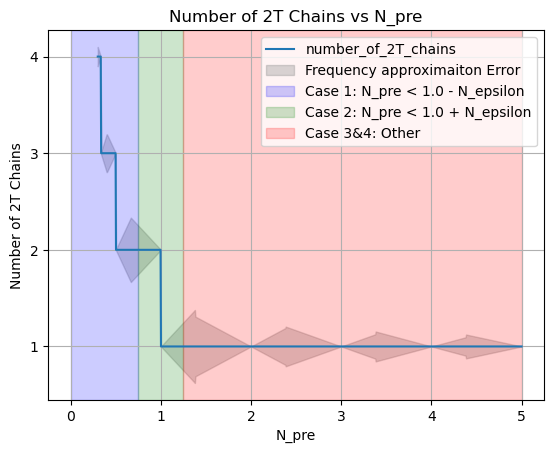

In [3]:

# Calculate the absolute error
f_calc_accuracy = np.abs(actual_f_calc_values - desired_f_calc_values) / desired_f_calc_values
    

# Plot the results
plt.plot(N_pre_values, chains_values, label='number_of_2T_chains')


# Plot the error area
plt.fill_between(N_pre_values, 
                 [value - error for value, error in zip(chains_values, f_calc_accuracy)], 
                 [value + error for value, error in zip(chains_values, f_calc_accuracy)], 
                 color='gray', alpha=0.3, label='Frequency approximaiton Error')

# Add vertical color regions
plt.axvspan(0, 1.0 - N_epsilon, color='blue', alpha=0.2, label='Case 1: N_pre < 1.0 - N_epsilon')
plt.axvspan(1.0 - N_epsilon, 1.0 + N_epsilon, color='green', alpha=0.2, label='Case 2: N_pre < 1.0 + N_epsilon')
plt.axvspan(1.0 + N_epsilon, max(N_pre_values), color='red', alpha=0.2, label='Case 3&4: Other')

# Add labels and title
plt.xlabel('N_pre')
plt.ylabel('Number of 2T Chains')
plt.yticks(range(min(chains_values), max(chains_values) + 1))
plt.title('Number of 2T Chains vs N_pre')

# Add legend and grid
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

# Analyse sampling frequency approximation accuracy

More suitable plot depicts directly the approximation accuracy.

At this point the parameter ```N_epsilon``` has been already optimized. It was initially 0,1 but it seems that the value of 0,25 assures better approximation.

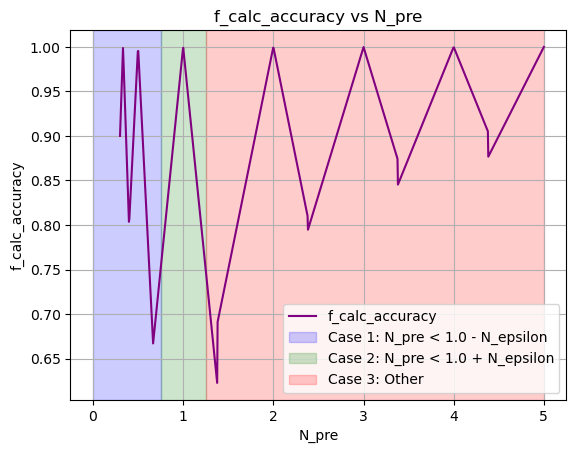

In [4]:
plt.plot(N_pre_values, 1-f_calc_accuracy, label='f_calc_accuracy', color='purple')

# Add vertical color regions
plt.axvspan(0, 1.0 - N_epsilon, color='blue', alpha=0.2, label='Case 1: N_pre < 1.0 - N_epsilon')
plt.axvspan(1.0 - N_epsilon, 1.0 + N_epsilon, color='green', alpha=0.2, label='Case 2: N_pre < 1.0 + N_epsilon')
plt.axvspan(1.0 + N_epsilon, max(N_pre_values), color='red', alpha=0.2, label='Case 3: Other')


# Add labels and title
plt.xlabel('N_pre')
plt.ylabel('f_calc_accuracy')
plt.title('f_calc_accuracy vs N_pre')

# Add legend and grid
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

# Calculate average accuracy in the range of ```N_pre```

In [5]:
# Integrate 1 - f_calc_accuracy
integral = np.trapz(1 - f_calc_accuracy, dx=(N_pre_values[1] - N_pre_values[0])) / N_pre_values[-1]
print(f"Normalized integral of (1 - f_calc_accuracy): {integral:.3f}")

Normalized integral of (1 - f_calc_accuracy): 0.840


## Results

| Case 1 function | Case 3 function | ```N_epsilon``` | Case 3 rounding correction | Normalized integrated ```1 - f_calc_accuracy``` | Notes                           |
|-----------------|-----------------|-----------------|----------------------------|-------------------------------------------------|---------------------------------|
| ```np.ceil()``` | ```round()```   | 0,1             | not used                   | **0,813**                                       | Initial solution                |
| -\|\|-          | -\|\|-          | 0,25            | not used                   | **0,827**                                       | Optimized ```N_epsilon```       |
| ```round()```   | ```round()```   | 0,25            | not used                   | **0,835**                                       | Optimized Case 3 function       |
| ```round()```   | ```round()```   | 0,25            | +0,12                      | **0,840**                                       | Introduced and optimized coefficient in Case 3 |
|                 |                 |                 |                            |                                                 |                                 |